In [17]:
import pandas as pd

all data sourced from https://open.toronto.ca/ on May 19, 2026

- City Wards https://open.toronto.ca/dataset/city-wards/
- Cycling Network https://open.toronto.ca/dataset/cycling-network/ 
- Permanent Bicycle Counters https://open.toronto.ca/dataset/permanent-bicycle-counters/ 

In [18]:
counter_locations = pd.read_csv("data/cycling_permanent_counts_locations.csv")
counter_locations.head()

,_id,location_dir_id,location_name,direction,linear_name_full,side_street,longitude,latitude,centreline_id,bin_size,latest_calibration_study,first_active,last_active,date_decommissioned,technology
0,1,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,-79.368119,43.673805,8540609,00:15:00,NaN,1994-06-26,2019-06-13,2019-06-13,Induction - Other
1,2,2,"Bloor St E, west of Castle Frank Rd (retired)",Westbound,Bloor St E,Castle Frank Rd,-79.368119,43.673805,8540609,00:15:00,NaN,1994-06-26,2019-06-13,2019-06-13,Induction - Other
2,3,3,"Bloor St W, west of Oakmount Rd",Eastbound,Bloor St W,Oakmount Rd,-79.462570,43.654146,30042273,00:15:00,2025-07-23,2023-06-16,2026-04-14,NaN,Induction - Eco-Counter
3,4,4,"Bloor St W, west of Oakmount Rd",Westbound,Bloor St W,Oakmount Rd,-79.462570,43.654146,30042273,00:15:00,2025-07-23,2023-06-16,2026-04-14,NaN,Induction - Eco-Counter
4,5,5,"Bloor St W, west of Huron St",Eastbound,Bloor St W,Huron St,-79.402240,43.667065,1142672,00:15:00,2025-07-23,2022-10-27,2026-04-14,NaN,Induction - Eco-Counter


In [19]:
daily_counts = pd.read_csv("data/cycling_permanent_counts_daily.csv")
daily_counts.head()

,_id,location_dir_id,location_name,direction,linear_name_full,side_street,dt,daily_volume
0,1,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-06-26,1046
1,2,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-06-28,1571
2,3,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-06-29,1306
3,4,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-07-01,1150
4,5,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,1994-07-02,1007


In [20]:
readings_per_day = daily_counts.groupby("dt").size()

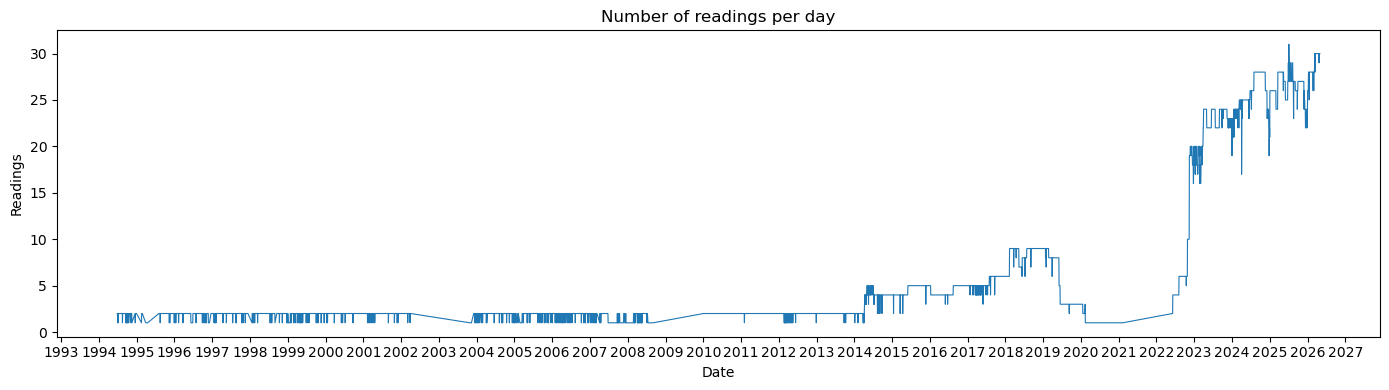

In [21]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(pd.to_datetime(readings_per_day.index), readings_per_day.values, linewidth=0.8)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set(title="Number of readings per day", xlabel="Date", ylabel="Readings")
plt.tight_layout()
plt.show()

In [22]:
stats = (
    daily_counts
    .groupby("location_dir_id")["daily_volume"]
    .agg(avg_daily_ridership="mean", peak_ridership="max")
    .reset_index()
)

locations = counter_locations.merge(stats, on="location_dir_id")
locations

,_id,location_dir_id,location_name,direction,linear_name_full,side_street,longitude,latitude,centreline_id,bin_size,latest_calibration_study,first_active,last_active,date_decommissioned,technology,avg_daily_ridership,peak_ridership
0,1,1,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,Bloor St E,Castle Frank Rd,-79.368119,43.673805,8540609,00:15:00,NaN,1994-06-26,2019-06-13,2019-06-13,Induction - Other,953.559411,4012
1,2,2,"Bloor St E, west of Castle Frank Rd (retired)",Westbound,Bloor St E,Castle Frank Rd,-79.368119,43.673805,8540609,00:15:00,NaN,1994-06-26,2019-06-13,2019-06-13,Induction - Other,892.249187,4570
2,3,3,"Bloor St W, west of Oakmount Rd",Eastbound,Bloor St W,Oakmount Rd,-79.462570,43.654146,30042273,00:15:00,2025-07-23,2023-06-16,2026-04-14,NaN,Induction - Eco-Counter,454.914873,1150
3,4,4,"Bloor St W, west of Oakmount Rd",Westbound,Bloor St W,Oakmount Rd,-79.462570,43.654146,30042273,00:15:00,2025-07-23,2023-06-16,2026-04-14,NaN,Induction - Eco-Counter,481.275930,1272
4,5,5,"Bloor St W, west of Huron St",Eastbound,Bloor St W,Huron St,-79.402240,43.667065,1142672,00:15:00,2025-07-23,2022-10-27,2026-04-14,NaN,Induction - Eco-Counter,1541.440767,4285
5,6,6,"Bloor St W, west of Huron St",Westbound,Bloor St W,Huron St,-79.402240,43.667065,1142672,00:15:00,2025-07-23,2022-10-27,2026-04-14,NaN,Induction - Eco-Counter,1484.673077,3881
6,7,7,"Bloor St W, west of Huron St (retired)",Westbound,Bloor St W,Huron St,-79.402221,43.666989,1142672,00:15:00,NaN,2018-02-09,2021-02-08,2022-06-02,Induction - Eco-Counter,1127.862782,2729
7,8,8,"Bloor St W, east of Palmerston Blvd",Eastbound,Bloor St W,Palmerston Blvd,-79.413093,43.664726,8353520,00:15:00,2025-07-23,2023-03-31,2026-04-14,NaN,Induction - Eco-Counter,2027.239325,4149
8,9,9,"Bloor St W, east of Palmerston Blvd",Westbound,Bloor St W,Palmerston Blvd,-79.413093,43.664726,8353520,00:15:00,2025-07-23,2023-03-31,2026-04-14,NaN,Induction - Eco-Counter,1810.572954,3647
9,10,10,"Bloor St W, east of Palmerston Blvd (retired)",Eastbound,Bloor St W,Palmerston Blvd,-79.413079,43.664724,8353520,00:15:00,NaN,2018-02-09,2020-02-11,2020-02-12,Induction - Eco-Counter,1172.326949,2954


In [23]:
locations.to_json("data/cleaned/counter_locations_with_stats.json", index=False)

In [24]:
daily_counts["dt"] = pd.to_datetime(daily_counts["dt"])

# Normalize: use the min centreline_id per location_name so directions at the same
# physical location always share one canonical ID (fixes Millwood split)
_canonical = counter_locations.groupby("location_name")["centreline_id"].transform("min")
counter_locations = counter_locations.copy()
counter_locations["centreline_id"] = _canonical

dir_stats = (
    daily_counts
    .groupby(["location_dir_id", "direction"])["daily_volume"]
    .agg(avg="mean", peak="max")
    .reset_index()
)

# Peak date: date of the max daily_volume per counter/direction
peak_date = (
    daily_counts
    .loc[daily_counts.groupby(["location_dir_id", "direction"])["daily_volume"].idxmax()]
    [["location_dir_id", "direction", "dt"]]
    .rename(columns={"dt": "peak_date"})
)

miss_rate = (
    daily_counts
    .groupby(["location_dir_id", "direction"])["dt"]
    .agg(first_entry="min", last_entry="max", days_with_readings="count")
    .reset_index()
)
miss_rate["miss_rate"] = (
    1 - miss_rate["days_with_readings"] /
    ((miss_rate["last_entry"] - miss_rate["first_entry"]).dt.days + 1)
)

dir_stats = (
    dir_stats
    .merge(peak_date, on=["location_dir_id", "direction"])
    .merge(miss_rate[["location_dir_id", "direction", "miss_rate"]], on=["location_dir_id", "direction"])
)

# Pivot so each direction becomes its own columns
dir_stats_wide = dir_stats.pivot(index="location_dir_id", columns="direction", values=["avg", "peak", "peak_date", "miss_rate"])
dir_stats_wide.columns = [f"{stat}_{dir.lower()}" for stat, dir in dir_stats_wide.columns]
dir_stats_wide = dir_stats_wide.reset_index()

# Keep one row per physical counter (centreline_id), take shared metadata from the first row
meta_cols = ["location_name", "linear_name_full", "side_street", "longitude", "latitude", "technology"]
meta = counter_locations.groupby("centreline_id")[meta_cols].first().reset_index()

# Map location_dir_id → centreline_id via counter_locations, then merge
loc_id_to_centreline = counter_locations[["location_dir_id", "centreline_id"]]
dir_stats_wide = dir_stats_wide.merge(loc_id_to_centreline, on="location_dir_id").drop(columns="location_dir_id")

# One row per centreline; .first() returns first non-null per column, so both
# directions of a merged counter (e.g. Millwood) are captured correctly
counters = meta.merge(
    dir_stats_wide.groupby("centreline_id").first().reset_index(),
    on="centreline_id"
)

# Combined peak: sum all directions per day per centreline, then find the max day
daily_with_cid = daily_counts.merge(
    counter_locations[["location_dir_id", "centreline_id"]], on="location_dir_id"
)
daily_combined = daily_with_cid.groupby(["centreline_id", "dt"])["daily_volume"].sum()
peak_combined_idx = daily_combined.groupby("centreline_id").idxmax()
peak_combined = daily_combined[peak_combined_idx].rename("peak_combined").reset_index()
peak_combined_date = peak_combined_idx.map(lambda idx: idx[1]).rename("peak_combined_date").reset_index()
counters = counters.merge(peak_combined[["centreline_id", "peak_combined"]], on="centreline_id")
counters = counters.merge(peak_combined_date, on="centreline_id")

counters.to_json("data/cleaned/counters_combined_directions.json", orient="records", indent=2, date_format="iso")
counters.head()

,centreline_id,location_name,linear_name_full,side_street,longitude,latitude,technology,avg_eastbound,avg_northbound,avg_southbound,...,peak_date_eastbound,peak_date_northbound,peak_date_southbound,peak_date_westbound,miss_rate_eastbound,miss_rate_northbound,miss_rate_southbound,miss_rate_westbound,peak_combined,peak_combined_date
0,439433,"Keele St, north of Four Winds Dr (multi-use path)",Keele St,Four Winds Dr,-79.491920,43.766102,Induction - Eco-Counter,None,33.56155,37.529947,...,NaT,2022-06-27,2022-06-27,NaT,None,0.075843,0.073736,None,247,2022-06-27
1,1140465,"Yonge St, north of Macpherson Ave",Yonge St,Macpherson Ave,-79.390566,43.679541,Induction - Eco-Counter,None,540.506292,789.660714,...,NaT,2024-09-17,2025-06-17,NaT,None,0.182753,0.338257,None,2861,2024-09-17
2,1142672,"Bloor St W, west of Huron St",Bloor St W,Huron St,-79.402240,43.667065,Induction - Eco-Counter,1541.440767,None,None,...,2025-09-16,NaT,NaT,2025-09-16,0.552262,None,None,0.553822,8166,2025-09-16
3,1143580,"Sherbourne St, north of Gerrard St",Sherbourne St,Gerrard St,-79.372567,43.662038,Induction - Eco-Counter,None,635.110405,733.460683,...,NaT,2025-09-03,2024-06-12,NaT,None,0.003956,0.003956,None,4477,2016-09-20
4,3232748,"Millwood Rd, north of Pape Ave/Donlands Ave",Millwood Rd,Donlands Ave,-79.348918,43.697263,Induction - Eco-Counter,None,29.733333,123.616667,...,NaT,2025-07-09,2025-07-09,NaT,None,0.684211,0.684211,None,981,2025-07-09


In [25]:
daily_counts["dt"] = pd.to_datetime(daily_counts["dt"])

coverage = (
    daily_counts
    .groupby("location_dir_id")["dt"]
    .agg(first_entry="min", last_entry="max", days_with_readings="count")
    .reset_index()
)
coverage["days_in_range"] = (coverage["last_entry"] - coverage["first_entry"]).dt.days + 1
coverage["days_missed"]   = coverage["days_in_range"] - coverage["days_with_readings"]
coverage["miss_rate"]  = (coverage["days_missed"] / coverage["days_in_range"])

coverage = coverage.merge(
    counter_locations[["location_dir_id", "location_name", "direction"]],
    on="location_dir_id"
)

coverage[["location_name", "direction", "first_entry", "last_entry", "days_in_range", "days_with_readings", "days_missed", "miss_rate"]].sort_values("miss_rate", ascending=False)

,location_name,direction,first_entry,last_entry,days_in_range,days_with_readings,days_missed,miss_rate
39,"Millwood Rd, north of Pape Ave/Donlands Ave",Northbound,2025-01-01,2025-07-09,190,60,130,0.684211
40,"Millwood Rd, north of Pape Ave/Donlands Ave",Southbound,2025-01-01,2025-07-09,190,60,130,0.684211
5,"Bloor St W, west of Huron St",Westbound,2022-10-27,2026-04-30,1282,572,710,0.553822
4,"Bloor St W, west of Huron St",Eastbound,2022-10-27,2026-04-30,1282,574,708,0.552262
1,"Bloor St E, west of Castle Frank Rd (retired)",Westbound,1994-06-26,2019-06-13,9119,5839,3280,0.359689
30,"Yonge St, north of Macpherson Ave",Southbound,2024-06-23,2026-04-30,677,448,229,0.338257
38,"Murray Ross Pkwy, north of Shoreham Dr (multi-...",Southbound,2022-05-31,2026-04-30,1431,964,467,0.326345
37,"Murray Ross Pkwy, north of Shoreham Dr (multi-...",Northbound,2022-05-31,2026-04-30,1431,966,465,0.324948
0,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound,1994-06-26,2019-06-13,9119,6253,2866,0.314289
19,"Sherbourne St, north of Gerrard St (retired)",Northbound,2014-04-11,2019-06-02,1879,1510,369,0.196381


In [26]:
coverage

,location_dir_id,first_entry,last_entry,days_with_readings,days_in_range,days_missed,miss_rate,location_name,direction
0,1,1994-06-26,2019-06-13,6253,9119,2866,0.314289,"Bloor St E, west of Castle Frank Rd (retired)",Eastbound
1,2,1994-06-26,2019-06-13,5839,9119,3280,0.359689,"Bloor St E, west of Castle Frank Rd (retired)",Westbound
2,3,2023-06-16,2026-04-30,1022,1050,28,0.026667,"Bloor St W, west of Oakmount Rd",Eastbound
3,4,2023-06-16,2026-04-30,1022,1050,28,0.026667,"Bloor St W, west of Oakmount Rd",Westbound
4,5,2022-10-27,2026-04-30,574,1282,708,0.552262,"Bloor St W, west of Huron St",Eastbound
5,6,2022-10-27,2026-04-30,572,1282,710,0.553822,"Bloor St W, west of Huron St",Westbound
6,7,2018-02-09,2021-02-08,1064,1096,32,0.029197,"Bloor St W, west of Huron St (retired)",Westbound
7,8,2023-03-31,2026-04-30,1007,1127,120,0.106477,"Bloor St W, east of Palmerston Blvd",Eastbound
8,9,2023-03-31,2026-04-30,1124,1127,3,0.002662,"Bloor St W, east of Palmerston Blvd",Westbound
9,10,2018-02-09,2020-02-11,731,733,2,0.002729,"Bloor St W, east of Palmerston Blvd (retired)",Eastbound


In [27]:
(daily_counts.groupby(['location_dir_id', "dt"])
    .size()
    .reset_index(name='count')
    .query('count > 1')
    )

,location_dir_id,dt,count


In [28]:
import plotly.express as px

fig = px.scatter(
    dir_stats.merge(counter_locations[["location_dir_id", "location_name"]], on="location_dir_id"),
    x="avg", y="miss_rate",
    hover_data=["location_name", "direction"],
    labels={"avg": "Avg daily ridership", "miss_rate": "Miss rate"},
    title="Avg daily ridership vs. miss rate (per counter direction)",
)
fig.update_yaxes(tickformat=".0%")
fig.show()


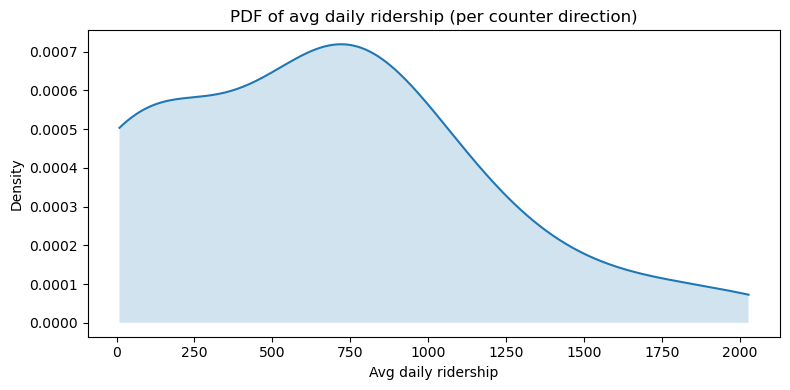

In [29]:
from scipy.stats import gaussian_kde
import numpy as np

x = dir_stats["avg"].dropna()
kde = gaussian_kde(x)
x_range = np.linspace(x.min(), x.max(), 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_range, kde(x_range))
ax.fill_between(x_range, kde(x_range), alpha=0.2)
ax.set(title="PDF of avg daily ridership (per counter direction)", xlabel="Avg daily ridership", ylabel="Density")
plt.tight_layout()
plt.show()

In [30]:
import json

# Normalize centreline_id by location_name (same fix as export cell)
_locs = counter_locations.copy()
_canonical = _locs.groupby("location_name")["centreline_id"].transform("min")
_locs["centreline_id"] = _canonical

daily_with_dir = (
    daily_counts
    .merge(_locs[["location_dir_id", "centreline_id"]], on="location_dir_id")
    .sort_values(["centreline_id", "direction", "dt"])
)

result = {}
for cid, grp in daily_with_dir.groupby("centreline_id"):
    combined = grp.groupby("dt")["daily_volume"].sum().reset_index().sort_values("dt")

    directions = {
        direction.lower(): {
            "dates":   dgrp["dt"].dt.strftime("%Y-%m-%d").tolist(),
            "volumes": dgrp["daily_volume"].tolist(),
        }
        for direction, dgrp in grp.groupby("direction")
    }

    result[str(int(cid))] = {
        "dates":      combined["dt"].dt.strftime("%Y-%m-%d").tolist(),
        "volumes":    combined["daily_volume"].tolist(),
        "directions": directions,
    }

with open("data/cleaned/counters_daily.json", "w") as f:
    json.dump(result, f)

print(f"Exported {len(result)} counters")

Exported 17 counters
